In [542]:
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob 

In [544]:
folder_path = "../data1"

os.path.join(folder_path, "*.csv") 

'../data1\\*.csv'

In [546]:
x = glob.glob(os.path.join(folder_path, "*.csv")) 
x 

['../data1\\begin_inventory.csv',
 '../data1\\end_inventory.csv',
 '../data1\\purchases.csv',
 '../data1\\purchase_prices.csv',
 '../data1\\vendor_invoice.csv']

In [548]:
os.path.basename(x[0])

'begin_inventory.csv'

In [550]:
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

for file in csv_files:
    print("File:", os.path.basename(file))
    df = pd.read_csv(file)
    print("Shape:", df.shape)
    display(df.head()) 

File: begin_inventory.csv
Shape: (206529, 9)


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


File: end_inventory.csv
Shape: (224489, 9)


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


File: purchases.csv
Shape: (2372474, 16)


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


File: purchase_prices.csv
Shape: (12261, 9)


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


File: vendor_invoice.csv
Shape: (5543, 10)


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN


In [552]:
print(os.listdir("../data1")) 

['.ipynb_checkpoints', 'begin_inventory.csv', 'end_inventory.csv', 'purchases.csv', 'purchase_prices.csv', 'vendor_invoice.csv']


In [554]:
vendor_df = pd.read_csv("../data1/vendor_invoice.csv")
vendor_df

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN
...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,NaN
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,NaN
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,NaN
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,NaN


# EDA

In [557]:
print("Neumerical columns:")
vendor_df.describe().round()

Neumerical columns:


,VendorNumber,PONumber,Quantity,Dollars,Freight
count,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0
std,34582.0,1601.0,14453.0,140234.0,714.0
min,2.0,8106.0,1.0,4.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0
50%,7240.0,10890.0,423.0,4765.0,25.0
75%,10754.0,12276.0,5100.0,44587.0,230.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0


In [559]:
print("Categorical columns:")
categorical_columns = vendor_df.select_dtypes(include = ["object"]).columns.tolist()
print(categorical_columns)

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna = False).head(10))

Categorical columns:
['VendorName', 'InvoiceDate', 'PODate', 'PayDate', 'Approval']

--- VendorName ---
VendorName
AMERICAN VINTAGE BEVERAGE      55
SAZERAC CO INC                 55
BACARDI USA INC                55
BANFI PRODUCTS CORP            55
BROWN-FORMAN CORP              55
CHARLES JACQUIN ET CIE INC     55
CONSTELLATION BRANDS INC       55
CASTLE BRANDS CORP.            55
CAMPARI AMERICA                55
CRUSH WINES                    55
Name: count, dtype: int64

--- InvoiceDate ---
InvoiceDate
2024-07-04    43
2024-07-11    35
2025-01-03    33
2024-08-08    32
2024-08-16    31
2024-02-22    31
2024-07-12    31
2024-05-31    30
2024-09-20    30
2024-10-04    30
Name: count, dtype: int64

--- PODate ---
PODate
2024-06-25    86
2024-09-23    76
2024-03-18    26
2024-07-01    26
2024-10-26    25
2024-03-22    24
2024-02-09    24
2024-12-21    24
2024-08-08    24
2024-04-19    24
Name: count, dtype: int64

--- PayDate ---
PayDate
2024-08-14    31
2024-08-12    30
2024-11-12  

In [561]:
date_columns = ["InvoiceDate", "PODate", "PayDate"]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors = "coerce")

print("Date ranges : ")

for col in date_columns:
    print(f"{col} : " f"{df[col].min().date()} → " f"{df[col].max().date()}")

Date ranges : 
InvoiceDate : 2024-01-04 → 2025-01-10
PODate : 2023-12-20 → 2024-12-23
PayDate : 2024-02-04 → 2025-02-19


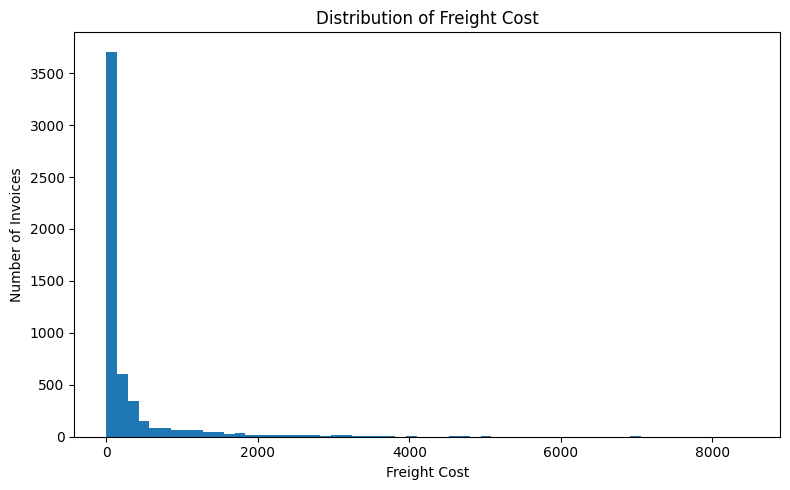

In [563]:
plt.figure(figsize=(8, 5))

plt.hist(df["Freight"], bins = 60)

plt.xlabel("Freight Cost") 
plt.ylabel("Number of Invoices")
plt.title("Distribution of Freight Cost")

plt.tight_layout()
plt.show()

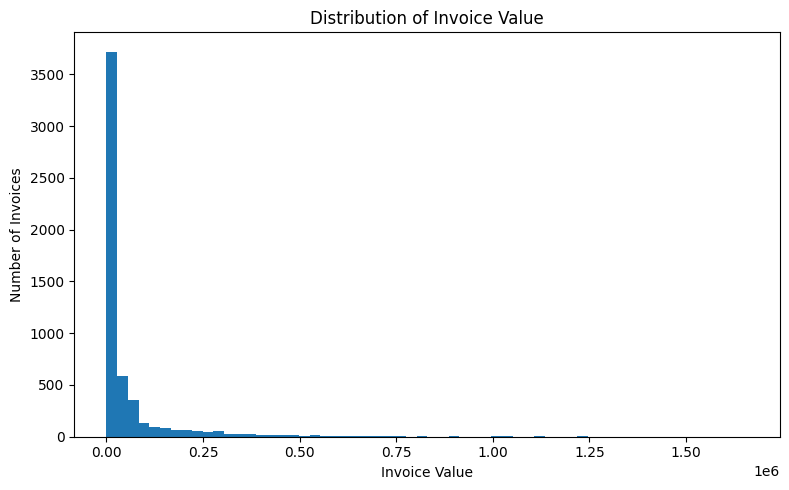

In [565]:
plt.figure(figsize=(8, 5))

plt.hist(df["Dollars"], bins = 60)

plt.xlabel("Invoice Value")
plt.ylabel("Number of Invoices")
plt.title("Distribution of Invoice Value")

plt.tight_layout()
plt.show()

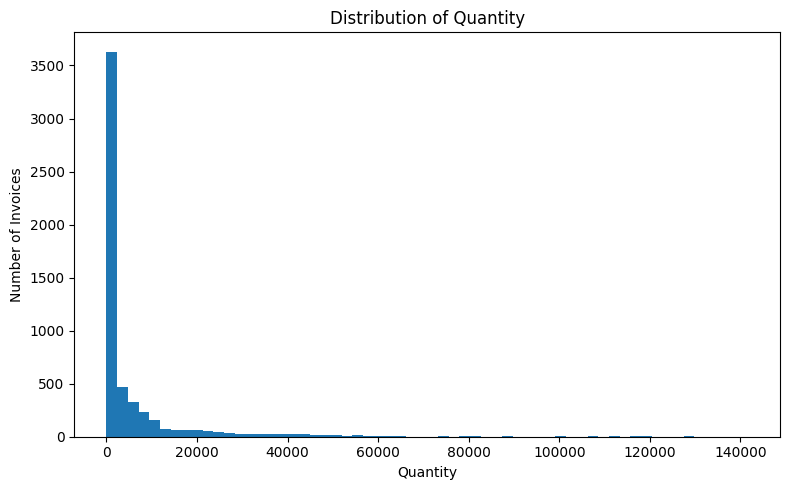

In [567]:
plt.figure(figsize=(8, 5))

plt.hist(df["Quantity"], bins = 60)

plt.xlabel("Quantity")
plt.ylabel("Number of Invoices")
plt.title("Distribution of Quantity")

plt.tight_layout()
plt.show() 

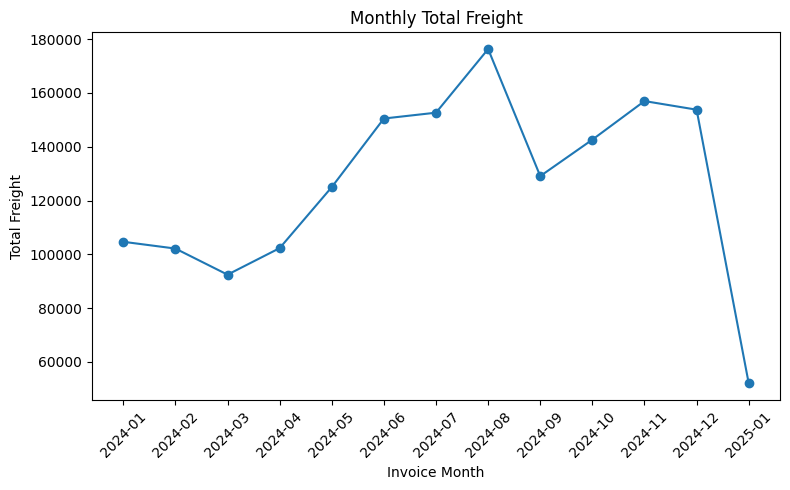

In [569]:
df["InvoiceMonthPeriod"] = (df["InvoiceDate"].dt.to_period("M"))

monthly_freight = (df.groupby("InvoiceMonthPeriod")["Freight"].sum())

plt.figure(figsize = (8, 5))
plt.plot(monthly_freight.index.astype(str), monthly_freight.values, marker = "o")
plt.xticks(rotation = 45)

plt.xlabel("Invoice Month")
plt.ylabel("Total Freight")
plt.title("Monthly Total Freight")

plt.tight_layout()
plt.show()

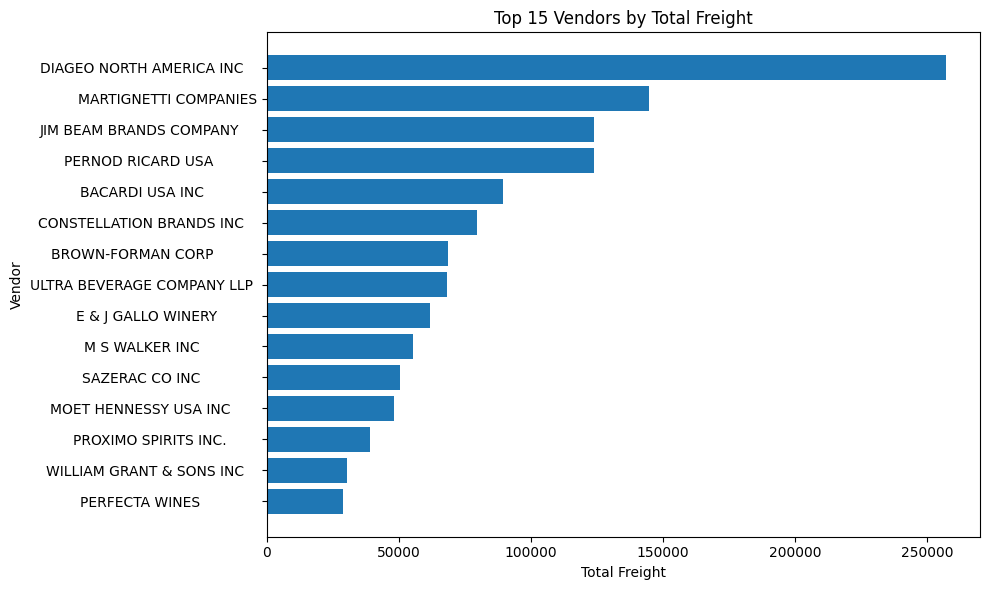

In [571]:
top_vendors = (df.groupby("VendorName")["Freight"].sum().sort_values(ascending = False).head(15).sort_values())

plt.figure(figsize=(10, 6))

plt.barh(top_vendors.index, top_vendors.values)

plt.xlabel("Total Freight")
plt.ylabel("Vendor")
plt.title("Top 15 Vendors by Total Freight")

plt.tight_layout()
plt.show()

In [573]:
vendor_df['Freight_per_unit'] = vendor_df['Freight'] / vendor_df['Quantity']
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,Freight_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN,0.221809


In [583]:
for col in ["Quantity", "Dollars", "Freight"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col:10s}: " f"{outliers:,} potential outliers")

Quantity  : 701 potential outliers
Dollars   : 748 potential outliers
Freight   : 738 potential outliers


In [585]:
vendor_df[['Quantity', 'Dollars', 'Freight']].corr() 

,Quantity,Dollars,Freight
Quantity,1.000000,0.963831,0.946550
Dollars,0.963831,1.000000,0.985141
Freight,0.946550,0.985141,1.000000


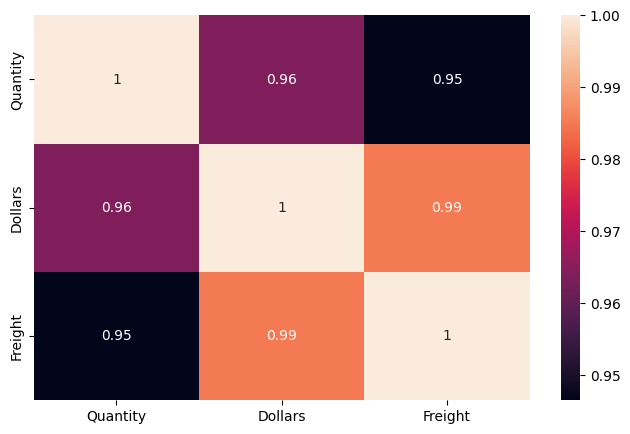

In [587]:
plt.figure(figsize = (8, 5))
sns.heatmap(vendor_df[['Quantity', 'Dollars', 'Freight']].corr(), annot = True)
plt.show()

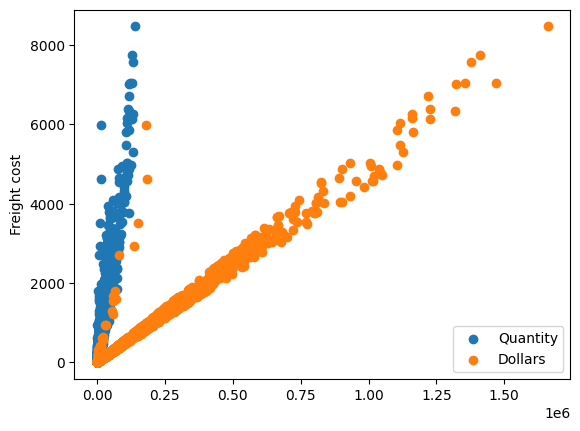

In [589]:
plt.scatter(vendor_df['Quantity'], vendor_df['Freight']) 
plt.scatter(vendor_df['Dollars'], vendor_df['Freight'])
plt.legend(['Quantity', 'Dollars'])
plt.ylabel('Freight cost')
plt.show()

In [591]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
low_quantity

np.float64(83.0)

In [593]:
high_quantity = vendor_df['Quantity'].quantile(0.75)
high_quantity

np.float64(5100.5)

In [595]:
# avg freight cost when low quantity

vendor_df.loc[vendor_df['Quantity'] < low_quantity, 'Freight_per_unit'].mean() 

np.float64(0.09489854253138316)

In [597]:
# avg freight cost when high quantity

vendor_df.loc[vendor_df['Quantity'] > high_quantity, 'Freight_per_unit'].mean()

np.float64(0.049077654690759046)

# MODEL BUILDING

In [600]:
X = vendor_df[['Quantity', 'Dollars', 'Freight_per_unit']]

In [602]:
y = vendor_df['Freight']

In [604]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 20) 

In [606]:
X_train

,Quantity,Dollars,Freight_per_unit
1356,107,807.73,0.038505
3368,2671,61411.05,0.112658
1446,78,879.48,0.052949
4201,63,1384.83,0.112063
1699,130,1074.90,0.037231
...,...,...,...
1607,16090,199050.33,0.064329
3915,41,638.40,0.085610
1428,36,284.04,0.041944
4367,48,1051.20,0.105208


In [608]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [610]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [612]:
model2 = DecisionTreeRegressor(max_depth = 6, random_state = 42)
model2.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [614]:
model3 = RandomForestRegressor(max_depth = 6, random_state = 20)
model3.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [616]:
def evaluate_model(model, X_test, y_Test, model_name):
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds) 

    print(f'\n{model_name} performance : ')
    print(f'MAE      : {mae:.2f}')
    print(f'RMSE     : {rmse:.2f}')
    print(f'R2-SCORE : {r2:.2f}') 

In [618]:
evaluate_model(model1, X_test, y_test, 'Linear Regression')
evaluate_model(model2, X_test, y_test, 'Decision Tree Regression')
evaluate_model(model3, X_test, y_test, 'Random Forest Regression') 


Linear Regression performance : 
MAE      : 33.22
RMSE     : 197.47
R2-SCORE : 0.94

Decision Tree Regression performance : 
MAE      : 32.45
RMSE     : 124.49
R2-SCORE : 0.98

Random Forest Regression performance : 
MAE      : 26.18
RMSE     : 111.65
R2-SCORE : 0.98


In [638]:
input_data = {
    'Quantity': [1935, 15],
    'Dollars': [15527.25, 140.55],
    'Freight_per_unit': [0.221809, 0.571333]
}

df = pd.DataFrame(input_data)
print(df)

   Quantity   Dollars  Freight_per_unit
0      1935  15527.25          0.221809
1        15    140.55          0.571333


In [640]:
model3.predict(df)

array([395.12895892,   3.12408873])

In [642]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model3, X, y, cv = 5, scoring = 'r2')
print("CV R2:", scores.mean())

CV R2: 0.9575916090297849
